In [ ]:
import numpy as np
import pandas as pds

In [2]:
dff = pd.read_csv("nexamart_raw.csv")

In [3]:
df = dff.copy()

In [4]:
df

,order_id,customer_id,order_date,category,product_name,quantity,unit_price,discount_pct,payment_method,channel,customer_age,customer_gender,region,city,delivery_days,rating,returned
0,ORD004768,CUST00650,2025-11-05,Electronics,Power Bank,1,1312.33,5.0,Debit Card,Mobile App,30.0,Male,North,Jaipur,6.0,2.0,False
1,ORD008969,CUST01679,2025-08-23,Fashion,Leather Wallet,2,810.15,5.0,Credit Card,Mobile App,19.0,Other,West,Ahmedabad,7.0,4.0,False
2,ORD001140,CUST00174,2025-11-15,Electronics,Laptop Stand,1,833.49,30.0,UPI,Website,47.0,Other,North,Jaipur,4.0,3.0,False
3,ORD002373,CUST00310,2024-12-10,Fashion,Running Shoes,1,2537.42,5.0,Credit Card,Website,50.0,Male,South,Kochi,5.0,3.0,False
4,ORD007900,CUST02077,2024-12-11,electronics,Bluetooth Speaker,1,1960.66,10.0,Debit Card,Mobile Web,55.0,Other,North,Chandigarh,5.0,2.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12175,ORD011965,CUST00445,07/12/2024,Home & Kitchen,Storage Organizer,2,475.24,5.0,UPI,Mobile App,62.0,Male,East,Bhubaneswar,9.0,5.0,False
12176,ORD005192,CUST00840,2024-10-08,Fashion,Leather Wallet,1,750.23,10.0,Cash on Delivery,Mobile App,38.0,Other,North,Jaipur,4.0,4.0,False
12177,ORD005391,CUST01241,2025-10-21,Fashion,Sunglasses,1,1054.89,15.0,Cash on Delivery,Mobile App,56.0,Female,East,Guwahati,7.0,3.0,False
12178,ORD000861,CUST00247,2025-08-02,Sports,Skipping Rope,1,197.36,0.0,Wallet,Mobile Web,58.0,Other,South,Kochi,4.0,5.0,False


In [5]:
dff.shape

(12180, 17)

In [6]:
df.duplicated().sum()

np.int64(115)

In [7]:
df.drop_duplicates(inplace= True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(12065, 17)

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 12065 entries, 0 to 12179
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         12065 non-null  str    
 1   customer_id      12065 non-null  str    
 2   order_date       12065 non-null  str    
 3   category         12065 non-null  str    
 4   product_name     12065 non-null  str    
 5   quantity         12065 non-null  int64  
 6   unit_price       12065 non-null  float64
 7   discount_pct     11884 non-null  float64
 8   payment_method   11944 non-null  str    
 9   channel          12065 non-null  str    
 10  customer_age     11704 non-null  float64
 11  customer_gender  12065 non-null  str    
 12  region           12065 non-null  str    
 13  city             12065 non-null  str    
 14  delivery_days    11825 non-null  float64
 15  rating           11099 non-null  float64
 16  returned         12065 non-null  bool   
dtypes: bool(1), float64(5), int6

In [11]:
df.reset_index(drop=True, inplace=True)

In [12]:
df.isnull().sum()

order_id             0
customer_id          0
order_date           0
category             0
product_name         0
quantity             0
unit_price           0
discount_pct       181
payment_method     121
channel              0
customer_age       361
customer_gender      0
region               0
city                 0
delivery_days      240
rating             966
returned             0
dtype: int64

In [13]:
# dff['Discount'] = dff['Discount'].fillna(dff['Discount'].mean())

df.columns = df.columns.str.strip().str.lower().str.title()

# for col in df.select_dtypes(include="object").columns:
#     df[col] = df[col].str.strip().str.title().str.replace(" ", "_")

In [14]:
df = df.replace(r'^\s*$',np.nan, regex=True)

In [15]:
# Clean only string/object columns in df
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.title().str.replace(" ", "_")

C:\Users\surya_t4rpfms\AppData\Local\Temp\ipykernel_3260\3284238158.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [16]:
count_age_100_150 = df[(df['Customer_Age'] >= 80) & (df['Customer_Age'] <= 150)].shape[0]
print(count_age_100_150)

12


In [17]:
df[df['Customer_Age'] > 100]

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,Customer_Age,Customer_Gender,Region,City,Delivery_Days,Rating,Returned
90,Ord002877,Cust01703,2025-11-20,Electronics,Bluetooth_Speaker,1,1906.13,20.0,Credit_Card,Mobile_App,120.0,Male,South,Bengaluru,5.0,3.0,True
531,Ord010625,Cust02033,2024-10-19,Home_&_Kitchen,Cushion_Cover,2,372.48,15.0,Credit_Card,Mobile_App,120.0,Other,East,Guwahati,10.0,5.0,False
1484,Ord008863,Cust01296,2025-10-09,Books,Cook_Book,1,471.79,10.0,Credit_Card,Website,150.0,Male,East,Patna,8.0,4.0,False
2608,Ord006202,Cust00220,2024-12-19,Books,Biography,1,399.78,0.0,Wallet,Website,150.0,Male,West,Mumbai,5.0,4.0,False
4018,Ord010546,Cust02234,2025-10-03,Beauty,Lipstick,1,529.50,10.0,Upi,Mobile_App,150.0,Female,East,Guwahati,6.0,5.0,False
5153,Ord008250,Cust00291,2024-06-13,Books,Cook_Book,1,475.12,15.0,Upi,Mobile_App,150.0,Male,West,Surat,5.0,4.0,False
7276,Ord001574,Cust02243,2025-03-25,Electronics,Power_Bank,1,1394.33,0.0,Debit_Card,Website,150.0,Female,East,Guwahati,10.0,5.0,False
8395,Ord008983,Cust00996,2025-09-16,Sports,Cycling_Gloves,2,516.86,20.0,Cash_On_Delivery,Mobile_App,120.0,Other,West,Mumbai,6.0,4.0,False
9150,Ord005411,Cust01237,2024-10-04,Beauty,Sunscreen,1,404.35,0.0,Cash_On_Delivery,Mobile_App,120.0,Female,West,Ahmedabad,2.0,NaN,False
11118,Ord005751,Cust01277,2024-11-01,Beauty,Sunscreen,1,391.29,15.0,Upi,Mobile_App,120.0,Other,South,Hyderabad,6.0,3.0,False


In [18]:
df.loc[df['Customer_Age'] > 100, 'Customer_Id']

90       Cust01703
531      Cust02033
1484     Cust01296
2608     Cust00220
4018     Cust02234
5153     Cust00291
7276     Cust02243
8395     Cust00996
9150     Cust01237
11118    Cust01277
11658    Cust02359
11820    Cust02051
Name: Customer_Id, dtype: str

In [19]:
df.loc[df['Customer_Id'] == "Cust01703"]

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,Customer_Age,Customer_Gender,Region,City,Delivery_Days,Rating,Returned
90,Ord002877,Cust01703,2025-11-20,Electronics,Bluetooth_Speaker,1,1906.13,20.0,Credit_Card,Mobile_App,120.0,Male,South,Bengaluru,5.0,3.0,True
3377,Ord010768,Cust01703,2024-11-09,Books,Biography,2,426.13,5.0,Credit_Card,Mobile_App,58.0,Male,South,Chennai,1.0,5.0,False
7126,Ord008380,Cust01703,2024-08-31,Fashion,Running_Shoes,1,2509.39,10.0,Debit_Card,Mobile_App,58.0,Male,South,Hyderabad,6.0,1.0,True
9437,Ord011527,Cust01703,2024-06-27,Books,Children'S_Book,3,258.54,20.0,Credit_Card,Mobile_App,58.0,Male,South,Bengaluru,6.0,2.0,True
11336,Ord007576,Cust01703,2024-03-31,Electronics,Wireless_Earbuds,2,1584.95,15.0,Cash_On_Delivery,Mobile_App,58.0,Male,South,Kochi,8.0,4.0,False
11418,Ord001192,Cust01703,2024-10-12,Electronics,Laptop_Stand,1,915.60,5.0,Debit_Card,Mobile_App,58.0,Male,South,Chennai,5.0,4.0,False


In [20]:
correct_ages = {
   " Cust01703":58,
"Cust02033":18,
"Cust01296":64,
"Cust00220":41,
"Cust02234":19,
"Cust00291":46,
"Cust02243":61,
"Cust00996":22,
"Cust01237":21,
"Cust01277":21,
"Cust02359":39,
"Cust02051":26
}

mask = df["Customer_Id"].isin(correct_ages.keys()) & (df["Customer_Age"] > 100)

df.loc[mask, "Customer_Age"] = df.loc[mask, "Customer_Id"].map(correct_ages)

In [21]:
# Suppose you know Cust02234's age is 19 because it has one nan value
df.loc[df['Customer_Id'] == "Cust00291", 'Customer_Age'] = 46

In [22]:
import pandas as pd

# Calculate mean age
mean_age = df['Customer_Age'].mean().__round__()

# Replace ages > 70 with mean
df.loc[df['Customer_Age'] > 70, 'Customer_Age'] = mean_age

print(df[['Customer_Age']].head())


   Customer_Age
0          30.0
1          19.0
2          47.0
3          50.0
4          55.0


In [23]:
df['Customer_Age'] = df['Customer_Age'].fillna(df['Customer_Age'].mean())
df['Discount_Pct'] = df['Discount_Pct'].fillna(df['Discount_Pct'].mean())

In [24]:
df['Customer_Age'] = df['Customer_Age'].abs()
df['Delivery_Days'] = df['Delivery_Days'].abs()

In [25]:
rating_probs

NameError: name 'rating_probs' is not defined

In [ ]:
import numpy as np

# Step 1: Count missing ratings
n_missing = df['Rating'].isnull().sum()

# Step 2: Get frequency counts of existing ratings
rating_counts = df['Rating'].value_counts()

# Step 3: Convert counts into probabilities
rating_probs = rating_counts / rating_counts.sum()

# Step 4: Randomly sample replacement values
fill_values = np.random.choice(
    rating_probs.index,       # list of rating values (1–5)
    size=n_missing,           # number of missing values
    p=rating_probs.values     # probability distribution
)

# Step 5: Assign sampled values back to missing rows
df.loc[df['Rating'].isnull(), 'Rating'] = fill_values

In [ ]:
df['Delivery_Days'].mean()

np.float64(5.509936575052854)

In [ ]:
# Fill missing Delivery_Days with the mean
df['Delivery_Days'] = df['Delivery_Days'].fillna(df['Delivery_Days'].mean())

In [ ]:
df['Delivery_Days'] = df['Delivery_Days'].astype(int)

In [ ]:
import numpy as np

# Step 1: Count missing payment methods
n_missing = df['Payment_Method'].isnull().sum()

# Step 2: Get frequency counts of existing payment methods
payment_counts = df['Payment_Method'].value_counts()

# Step 3: Convert counts into probabilities
payment_probs = payment_counts / payment_counts.sum()

# Step 4: Randomly sample replacement values
fill_values = np.random.choice(
    payment_probs.index,       # list of payment methods (e.g., UPI, Credit Card, NetBanking)
    size=n_missing,            # number of missing values
    p=payment_probs.values     # probability distribution
)

# Step 5: Assign sampled values back to missing rows
df.loc[df['Payment_Method'].isnull(), 'Payment_Method'] = fill_values


In [ ]:
df['Order_Date'] = pd.to_datetime(df['order_date'], format = "mixed")

KeyError: 'order_date'

In [ ]:
df['order_date']

0        2025-11-05
1        2025-08-23
2        2025-11-15
3        2024-12-10
4        2024-12-11
            ...    
12175    07/12/2024
12176    2024-10-08
12177    2025-10-21
12178    2025-08-02
12179    2024-08-23
Name: order_date, Length: 12180, dtype: str

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format = "mixed")
df['Customer_Age'] = df['Customer_Age'].astype(int)
df['Delivery_Days'] = df['Delivery_Days'].astype(int)

In [ ]:
df[df['Unit_Price'] > 50000]  # It is possible a frinder and watch can this much of cost

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,Customer_Age,Customer_Gender,Region,City,Delivery_Days,Rating,Returned
3195,Ord002401,Cust01620,2025-10-28,Electronics,Smart_Watch,1,76649.706706,15.0,Credit_Card,Mobile_App,28,Female,South,Bengaluru,7,2.0,True
4709,Ord008818,Cust00654,2024-12-01,Home_&_Kitchen,Mixer_Grinder,1,59865.591183,0.0,Cash_On_Delivery,Mobile_App,55,Male,East,Guwahati,6,4.0,False


In [ ]:
df[df['Quantity']> 100]  # we cant confirm say to remove based on the quantity

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,Customer_Age,Customer_Gender,Region,City,Delivery_Days,Rating,Returned
9164,Ord002395,Cust01234,2024-01-05,Fashion,Sunglasses,152,1077.38,10.0,Credit_Card,Mobile_App,45,Female,East,Bhubaneswar,13,3.0,True
9595,Ord007296,Cust02000,2025-12-15,Electronics,Wireless_Earbuds,114,1387.51,0.0,Cash_On_Delivery,Website,23,Female,North,Lucknow,7,5.0,False


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12065 entries, 0 to 12064
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_Id         12065 non-null  str           
 1   Customer_Id      12065 non-null  str           
 2   Order_Date       12065 non-null  datetime64[us]
 3   Category         12065 non-null  str           
 4   Product_Name     12065 non-null  str           
 5   Quantity         12065 non-null  int64         
 6   Unit_Price       12065 non-null  float64       
 7   Discount_Pct     12065 non-null  float64       
 8   Payment_Method   12065 non-null  str           
 9   Channel          12065 non-null  str           
 10  Customer_Age     12065 non-null  int64         
 11  Customer_Gender  12065 non-null  str           
 12  Region           12065 non-null  str           
 13  City             12065 non-null  str           
 14  Delivery_Days    12065 non-null  int64         
 

In [ ]:
df['Customer_Id'] = df['Customer_Id'].str.upper()
df['Order_Id'] = df['Order_Id'].str.upper()

# df[['Customer_Id','Order_Id']] = df[['Customer_Id','Order_Id']].apply(lambda x: x.str.strip().str.upper())

In [ ]:
# data cleaning completed

In [ ]:
df.to_csv("nextmart_cleaned_data.csv", index=False)

In [ ]:
df.to_excel("nextmartt_cleaned_data.xlsx", index=False)

In [ ]:
# questions

In [ ]:
#1.

In [ ]:
# Convert Discount_Pct from percentage points to decimal fractions
df['Discount_Pct'] = df['Discount_Pct'] / 100

In [ ]:
# Create Revenue column
df["Revenue"] = df["Quantity"] * df["Unit_Price"] * (1 - df["Discount_Pct"])

Month
1     0.067047
2     0.071542
3     0.055965
4     0.065123
5     0.059259
6     0.053272
7     0.060790
8     0.058741
9     0.071307
10    0.056174
11    0.062090
12    0.069630
Name: is_outlier, dtype: float64
Festive outlier rate: 0.06259265359907758
Non-festive outlier rate: 0.06239572906239573
Festive AOV: 1710.1791666542863
Non-festive AOV: 1711.7519970936478
Order_Date
2024-01    4.083243e+05
2024-02    3.767531e+05
2024-03    3.458124e+05
2024-04    3.531690e+05
2024-05    3.306590e+05
2024-06    3.499322e+05
2024-07    3.516080e+05
2024-08    3.825572e+05
2024-09    2.923873e+05
2024-10    1.126149e+06
2024-11    1.068009e+06
2024-12    1.133463e+06
2025-01    3.630224e+05
2025-02    3.153899e+05
2025-03    3.634625e+05
2025-04    4.076715e+05
2025-05    3.835607e+05
2025-06    3.512721e+05
2025-07    3.561744e+05
2025-08    3.936397e+05
2025-09    3.059321e+05
2025-10    1.113743e+06
2025-11    1.058019e+06
2025-12    1.074855e+06
Freq: M, Name: Revenue, dtype: float64

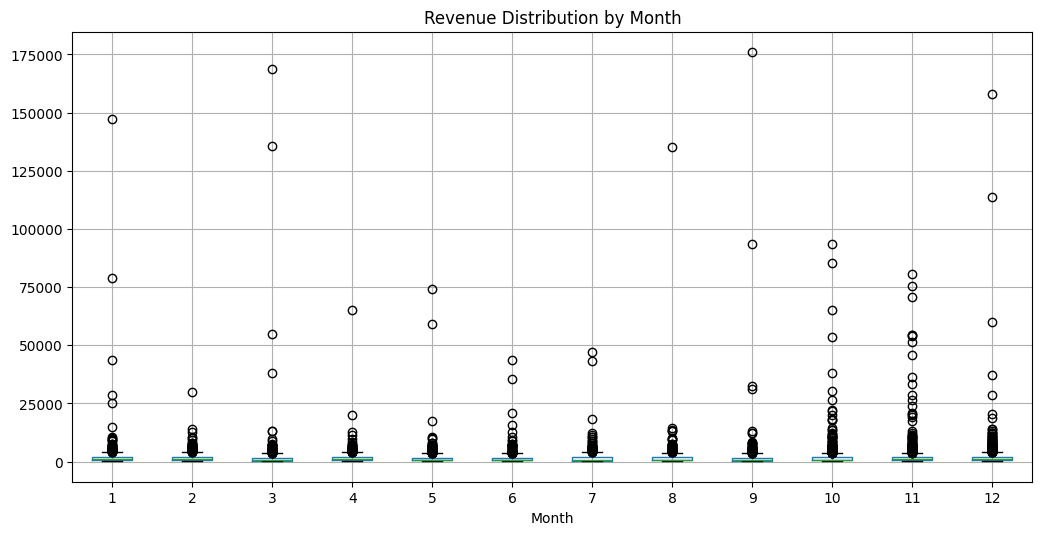

In [ ]:
# Convert Order_Date column to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Now you can extract the month
df['Month'] = df['Order_Date'].dt.month

Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR
df['is_outlier'] = (df['Revenue'] > upper) | (df['Revenue'] < lower)

df['Month'] = df['Order_Date'].dt.month

# outlier rate by month
print(df.groupby('Month')['is_outlier'].mean())

# festive vs non-festive comparison
festive = df[df['Month'].isin([10, 11, 12])]
nonfestive = df[~df['Month'].isin([10, 11, 12])]
print('Festive outlier rate:', festive['is_outlier'].mean())
print('Non-festive outlier rate:', nonfestive['is_outlier'].mean())
print('Festive AOV:', festive['Revenue'].mean())
print('Non-festive AOV:', nonfestive['Revenue'].mean())

# revenue recomputed with outliers removed
monthly_no_outliers = (
    df[~df['is_outlier']]
    .groupby(df['Order_Date'].dt.to_period('M'))['Revenue']
    .sum()
)
print(monthly_no_outliers)

# visual check
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='Revenue', by='Month', ax=ax)
ax.set_title('Revenue Distribution by Month')
plt.suptitle('')
plt.show()

In [ ]:
df.sample(5)

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,Customer_Age,Customer_Gender,Region,City,Delivery_Days,Rating,Returned,Revenue,Month,is_outlier
587,ORD009306,CUST02584,2024-03-27,Sports,Cycling_Gloves,1,463.38,0.0,Debit_Card,Mobile_App,38,Other,North,Chandigarh,10,3.0,False,463.380,3,False
10718,ORD007142,CUST02430,2024-10-25,Fashion,Men'S_T-Shirt,3,597.68,0.3,Upi,Mobile_App,40,Female,South,Chennai,5,3.0,False,1255.128,10,False
10955,ORD005409,CUST01427,2025-12-30,Books,Comic_Book,1,307.33,0.2,Credit_Card,Website,55,Male,East,Patna,8,4.0,False,245.864,12,False
3828,ORD003874,CUST00555,2025-10-07,Electronics,Smartphone_Case,3,427.45,0.0,Debit_Card,Website,42,Other,West,Mumbai,7,4.0,False,1282.350,10,False
5270,ORD009040,CUST02934,2025-03-17,Home_&_Kitchen,Storage_Organizer,3,453.30,0.0,Debit_Card,Website,27,Female,North,Chandigarh,8,5.0,False,1359.900,3,False


In [ ]:
monthly = df.groupby(df['Order_Date'].dt.to_period('M')).agg(
    revenue=('Revenue','sum'),
    orders=('Order_Id','nunique'),
    aov=('Revenue','mean')
).reset_index() # think
import locale
locale.setlocale(locale.LC_ALL, 'en_IN')  # Indian locale

monthly['revenue'] = monthly['revenue'].apply(lambda x: locale.format_string("%d", int(round(x)), grouping=True))
monthly

,Order_Date,revenue,orders,aov
0,2024-01,"7,60,856",362,2090.264739
1,2024-02,"5,34,831",330,1610.935308
2,2024-03,"6,55,234",341,1921.508781
3,2024-04,"5,35,048",334,1592.406062
4,2024-05,"4,57,066",333,1364.374872
5,2024-06,"4,80,970",327,1466.373045
6,2024-07,"5,28,439",325,1616.022055
7,2024-08,"6,63,462",347,1911.994436
8,2024-09,"7,19,312",293,2413.798569
9,2024-10,"17,06,384",1024,1658.293404


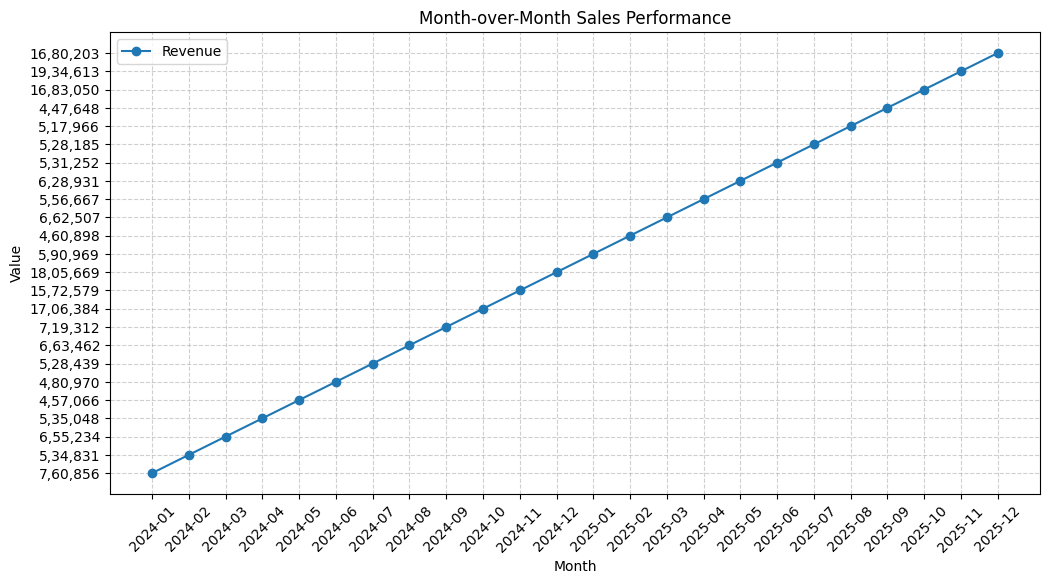

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(12,6))

# Plot each metric
plt.plot(monthly['Order_Date'].astype(str), monthly['revenue'], marker='o', label='Revenue')
# plt.plot(monthly['Order_Date'].astype(str), monthly['orders'], marker='o', label='Orders')
# plt.plot(monthly['Order_Date'].astype(str), monthly['aov'], marker='o', label='AOV')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Titles and labels
plt.title('Month-over-Month Sales Performance')
plt.xlabel('Month')
plt.ylabel('Value')

# Legend
plt.legend()

# Force plain numbers on y-axis (no scientific notation)
# plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))

# Add grid lines for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()



In [ ]:
#2.

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

Category
Electronics      7,911,630.73
Fashion          5,216,411.28
Home_&_Kitchen   2,962,022.28
Sports           2,145,796.40
Beauty           1,853,257.60
Books              553,620.90
Name: Revenue, dtype: float64

In [ ]:
category_revenue = df.groupby('Category')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)
region_revenue = df.groupby('Region')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)

In [ ]:
avg_category_revenue = category_revenue['Revenue'].mean()
underperforming_categories = category_revenue[category_revenue['Revenue'] < avg_category_revenue]

avg_region_revenue = region_revenue['Revenue'].mean()
underperforming_regions = region_revenue[region_revenue['Revenue'] < avg_region_revenue]


In [ ]:
underperforming_regions

,Region,Revenue
0,East,"4,926,478.40"


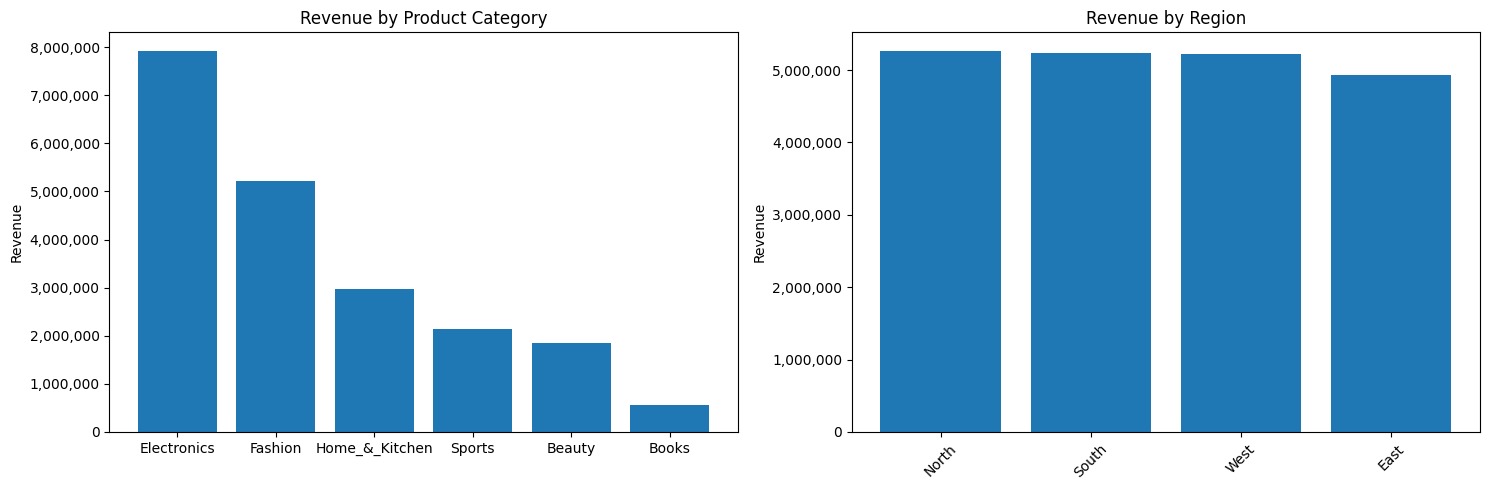

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(15,5))  # 1 row, 2 columns

# Category revenue
bars1 = axes[0].bar(category_revenue['Category'], category_revenue['Revenue'])
axes[0].set_title('Revenue by Product Category')
axes[0].set_ylabel('Revenue')
# Force y-axis to show plain numbers
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Region revenue
bars2 = axes[1].bar(region_revenue['Region'], region_revenue['Revenue'])
axes[1].set_title('Revenue by Region')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=45)
# Force y-axis to show plain numbers
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


In [ ]:
#3.

In [ ]:
df['Channel'].value_counts()

Channel
Mobile_App    6613
Website       3638
Mobile_Web    1814
Name: count, dtype: int64

In [ ]:
df.sample(2)

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,Customer_Age,Customer_Gender,Region,City,Delivery_Days,Rating,Returned,Revenue,Month,is_outlier
11381,ORD003710,CUST01483,2025-04-13,Sports,Football,1,688.16,0.00,Upi,Website,56,Other,East,Bhubaneswar,7,4.00,False,688.16,4,False
2471,ORD005710,CUST02354,2024-09-11,Electronics,Laptop_Stand,1,919.32,0.15,Cash_On_Delivery,Mobile_App,55,Male,West,Mumbai,4,3.00,False,781.42,9,False


In [ ]:
mobile_sales  = df.loc[df['Channel'] == 'Mobile_App', 'Revenue']
website_sales = df.loc[df['Channel'] == 'Website', 'Revenue']
# mobile_web_sales = df.loc[df['Channel'] == 'Mobile_Web', 'Revenue']

In [ ]:
print("Online AOV:", mobile_sales.mean())
print("Online AOV:", website_sales.mean())
# print("Offline AOV:", mobile_web_sales.mean())

Online AOV: 1713.04058445731
Online AOV: 1677.2881502435553


In [ ]:
from scipy.stats import ttest_ind, levene

# Check variance equality using Levene’s test
stat, p_var = levene(mobile_sales, website_sales)

if p_var > 0.05:
    # Variances are equal → Student’s t-test
    stat, p_val = ttest_ind(mobile_sales, website_sales, equal_var=True)
else:
    # Variances are unequal → Welch’s t-test
    stat, p_val = ttest_ind(mobile_sales, website_sales, equal_var=False)

print("Levenes test p-value:", p_var)
print("t-test statistic:", stat)
print("t-test p-value:", p_val)

# Decision rule
alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: means are significantly different.")
else:
    print("Fail to reject the null hypothesis: no significant difference in means.")

Levenes test p-value: 0.8813540188157593
t-test statistic: 0.3521138249548878
t-test p-value: 0.7247601402772481
Fail to reject the null hypothesis: no significant difference in means.


C:\Users\surya_t4rpfms\AppData\Local\Temp\ipykernel_7028\1217474385.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mobile_sales, website_sales], labels=['Online','Offline'])


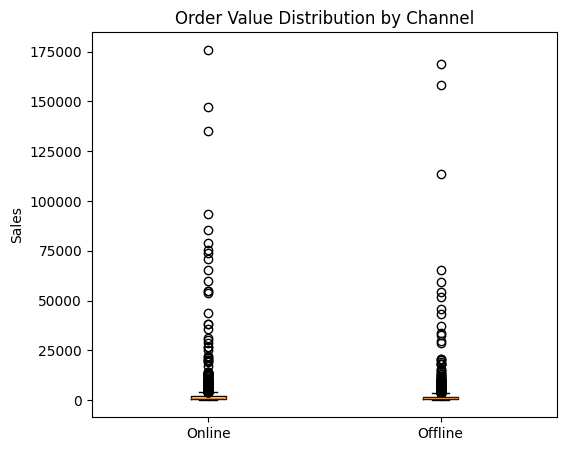

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.boxplot([mobile_sales, website_sales], labels=['Online','Offline'])
plt.title('Order Value Distribution by Channel')
plt.ylabel('Sales')
plt.show()


In [ ]:
#4.

In [ ]:
import pandas as pd
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Example dataset
df1 = pd.DataFrame({
    "Region": ["North"]*10 + ["South"]*10 + ["East"]*10 + ["West"]*10,
    "Revenue": [120,130,115,140,125,135,128,132,118,122,   # North
                150,160,155,148,162,158,151,149,157,154,   # South
                100,105,98,110,95,102,108,99,101,97,       # East
                130,135,128,132,129,131,134,133,127,136]   # West
})

# Step 1: ANOVA
groups = [df[df.Region == r]["Revenue"] for r in df["Region"].unique()]
f_stat, p_val = f_oneway(*groups)
print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_val)

# Step 2: Tukey only if ANOVA is significant
if p_val < 0.05:
    print("\nANOVA is significant → running Tukey HSD...")
    tukey = pairwise_tukeyhsd(endog=df["Revenue"], groups=df["Region"], alpha=0.05)
    print(tukey)

    # Step 3: Show mean revenue per region
    mean_revenues = df.groupby("Region")["Revenue"].mean().sort_values(ascending=False)
    print("\nAverage revenue by region (highest to lowest):")
    print(mean_revenues)

else:
    print("\nANOVA shows no significant differences → Tukey HSD not performed.")


ANOVA F-statistic: 0.4893691271824126
ANOVA p-value: 0.6896570560233592

ANOVA shows no significant differences → Tukey HSD not performed.


In [ ]:
import pandas as pd
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Assuming your DataFrame is named df and has columns: Region, Revenue

# Step 1: One-way ANOVA
groups = [df[df.Region == r]["Revenue"] for r in df["Region"].unique()]
f_stat, p_val = f_oneway(*groups)
print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_val)

# Step 2: Tukey HSD only if ANOVA is significant
if p_val < 0.05:
    print("\nANOVA is significant → running Tukey HSD...")
    tukey = pairwise_tukeyhsd(endog=df["Revenue"], groups=df["Region"], alpha=0.05)
    print(tukey)

    # Step 3: Ranked list of regions by mean revenue
    mean_revenues = df.groupby("Region")["Revenue"].mean().sort_values(ascending=False)
    print("\nRanked regions by mean revenue:")
    print(mean_revenues)

else:
    print("\nANOVA shows no significant differences → Tukey HSD not performed.")


ANOVA F-statistic: 0.4893691271824126
ANOVA p-value: 0.6896570560233592

ANOVA shows no significant differences → Tukey HSD not performed.


In [ ]:
#5.

In [ ]:
import pandas as pd
import scipy.stats as stats

# Contingency table: Category vs Returned (True/False)
contingency = pd.crosstab(df['Category'], df['Returned'])

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("Chi-square:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Result: Product category and return likelihood are associated (reject H0).")
else:
    print("Result: No significant association found (fail to reject H0).")


Chi-square: 263.7680589266707
p-value: 6.0964348411547686e-55
Result: Product category and return likelihood are associated (reject H0).


In [ ]:
#6.

In [ ]:
import pandas as pd
import scipy.stats as stats

# Pearson correlation: Discount % vs Rating (both numeric)
pearson_corr, pearson_p = stats.pearsonr(df['Discount_Pct'], df['Rating'])

print("Pearson correlation:", pearson_corr)
print("p-value:", pearson_p)

if pearson_p < 0.05:
    print("Answer: Yes, discount percentage and rating are correlated (reject H0).")
else:
    print("Answer: No significant correlation between discount percentage and rating (fail to reject H0).")


Pearson correlation: -0.012633921500078343
p-value: 0.1652492660772873
Answer: No significant correlation between discount percentage and rating (fail to reject H0).


In [ ]:
#7.

In [ ]:
df.sample()

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,Customer_Age,Customer_Gender,Region,City,Delivery_Days,Rating,Returned,Revenue,Month,is_outlier
2515,ORD008392,CUST00947,2025-11-28,Home_&_Kitchen,Storage_Organizer,2,472.23,0.00,Upi,Mobile_App,41,Female,North,Lucknow,1,4.00,False,944.46,11,False


In [ ]:
df.describe()

,Order_Date,Quantity,Unit_Price,Discount_Pct,Customer_Age,Delivery_Days,Rating,Revenue,Month
count,12065,"12,065.00","12,065.00","12,065.00","12,065.00","12,065.00","12,065.00","12,065.00","12,065.00"
mean,2025-02-14 08:43:50.551181,1.60,"1,151.30",0.08,41.25,5.50,3.87,"1,710.96",7.99
min,2024-01-01 00:00:00,1.00,183.18,0.00,3.00,1.00,1.00,128.74,1.00
25%,2024-10-01 00:00:00,1.00,421.23,0.00,30.00,4.00,3.00,474.02,5.00
50%,2025-01-03 00:00:00,1.00,797.77,0.05,41.00,5.00,4.00,884.09,10.00
75%,2025-10-02 00:00:00,2.00,"1,427.99",0.10,52.00,7.00,5.00,"1,839.62",11.00
max,2025-12-31 00:00:00,152.00,"76,649.71",0.30,64.00,14.00,5.00,"175,965.12",12.00
std,NaN,3.30,"1,765.47",0.08,13.25,2.21,0.98,"4,941.14",3.57


In [ ]:
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['Age_Group'] = pd.qcut(df['Customer_Age'], q=4, labels=labels)

print(df[['Customer_Age', 'Age_Group']].head())


   Customer_Age    Age_Group
0            30  Young Adult
1            19  Young Adult
2            47  Middle-aged
3            50  Middle-aged
4            55       Senior


In [ ]:
df.drop(columns=['Age_Group'], inplace=True)

In [ ]:
import pandas as pd

# Define bins and labels (covering all ages including <18)
bins = [0, 17, 35, 60, 120]   # 0–17, 18–35, 36–64, 65+
labels = ['Below 18', 'Young Adults (18-35)', 'Middle-Aged (36-64)', 'Seniors (65+)']

# Create Age_Group column
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=True)

print(df[['Customer_Age', 'Age_Group']].head())


   Customer_Age             Age_Group
0            30  Young Adults (18-35)
1            19  Young Adults (18-35)
2            47   Middle-Aged (36-64)
3            50   Middle-Aged (36-64)
4            55   Middle-Aged (36-64)


In [ ]:
age_group_revenue = df.groupby('Age_Group')['Revenue'].sum().sort_values(ascending= False)
print(age_group_revenue)
print("Middle-Aged customers customers buys more products")

Age_Group
Middle-Aged (36-64)    11,709,411.31
Young Adults (18-35)    7,220,217.28
Seniors (65+)           1,686,641.72
Below 18                   26,468.89
Name: Revenue, dtype: float64
Middle-Aged customers customers buys more products


In [ ]:
Gender_revenue = df.groupby('Customer_Gender')['Revenue'].sum().sort_values(ascending= False)
print(Gender_revenue)
print("Female generates more revenue")

Customer_Gender
Female   7,480,056.80
Other    6,695,223.20
Male     6,467,459.19
Name: Revenue, dtype: float64
Female generates more revenue


In [ ]:
#8.

In [ ]:
import pandas as pd

# Group by category and calculate totals and returns
return_stats = (
    df.groupby("Category")
      .agg(
          total_orders=("Order_Id", "count"),          # count total orders
          returned_orders=("Returned", "sum")          # sum of True values = number of returns
      )
)

# Calculate return rate as percentage
return_stats["return_rate_percent"] = (return_stats["returned_orders"] / return_stats["total_orders"]) * 100

# Sort categories by highest return rate
return_stats = return_stats.sort_values("return_rate_percent", ascending=False)

print(return_stats)


                total_orders  returned_orders  return_rate_percent
Category                                                          
Fashion                 2670              379                14.19
Electronics             2995              401                13.39
Books                    960               56                 5.83
Sports                  1403               73                 5.20
Beauty                  1842               95                 5.16
Home_&_Kitchen          2195              110                 5.01


In [ ]:
category = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
print(category)
print("Fashion and Electonics are more bringing category so should take care why they are returning")

Category
Electronics      7,911,630.73
Fashion          5,216,411.28
Home_&_Kitchen   2,962,022.28
Sports           2,145,796.40
Beauty           1,853,257.60
Books              553,620.90
Name: Revenue, dtype: float64
Fashion and Electonics are more bringing category so should take care why they are returning


In [ ]:
df.sample(2)

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,...,Customer_Gender,Region,City,Delivery_Days,Rating,Returned,Revenue,Month,is_outlier,Age_Group
8090,ORD008791,CUST02799,2025-10-11,Sports,Cricket_Bat,1,"1,459.03",0.15,Upi,Mobile_Web,...,Other,North,Jaipur,7,4.00,False,"1,240.18",10,False,Young Adults (18-35)
2766,ORD004973,CUST00622,2025-04-16,Fashion,Leather_Wallet,3,836.08,0.15,Net_Banking,Mobile_App,...,Female,South,Kochi,3,5.00,False,"2,132.00",4,False,Middle-Aged (36-64)


In [ ]:
#9.

In [ ]:
import pandas as pd
import scipy.stats as stats

# 1. Correlation: Delivery time vs. Rating
pearson_corr, pearson_p = stats.pearsonr(df['Delivery_Days'], df['Rating'])
print("Pearson correlation (Delivery Time vs Rating):", pearson_corr)
print("p-value:", pearson_p)

if pearson_p < 0.05:
    print("Result: Delivery time and rating are correlated (reject H0).")
else:
    print("Result: No significant correlation (fail to reject H0).")

# 2. Regional ANOVA: Delivery time by Region
groups = [df.loc[df['Region'] == region, 'Delivery_Days'] for region in df['Region'].unique()]
anova_f, anova_p = stats.f_oneway(*groups)

print("\nANOVA F-statistic:", anova_f)
print("ANOVA p-value:", anova_p)

if anova_p < 0.05:
    print("Result: Delivery time differs significantly across regions (reject H0).")
else:
    print("Result: No significant difference in delivery time across regions (fail to reject H0).")


Pearson correlation (Delivery Time vs Rating): 0.002928799345386576
p-value: 0.7477034624787182
Result: No significant correlation (fail to reject H0).

ANOVA F-statistic: 1093.105852203887
ANOVA p-value: 0.0
Result: Delivery time differs significantly across regions (reject H0).


In [ ]:
#. Analysis

In [ ]:
# import pandas as pd

# # Assuming df has columns: Sales, Profit, Quantity, OrderID
# # And each row = one order line

# # Total Sales
# total_sales = df['Revenue'].sum()

# # Total Profit
# total_profit = df['Profit'].sum()

# # Overall Profit Margin (%)
# overall_margin = (total_profit / total_sales) * 100

# # Total Orders (unique OrderID count)
# total_orders = df['OrderID'].nunique()

# # Average Order Value (AOV = Sales / Orders)
# aov = total_sales / total_orders

# # Average Quantity per Order
# avg_qty_per_order = df.groupby('OrderID')['Quantity'].sum().mean()

# # Loss-Making Orders (% of orders with negative profit)
# loss_orders = df.groupby('OrderID')['Profit'].sum()
# loss_rate = (loss_orders[loss_orders < 0].count() / total_orders) * 100

# # Print results
# print("Total Sales (Rs):", round(total_sales))
# print("Total Profit (Rs):", round(total_profit))
# print("Overall Profit Margin (%):", round(overall_margin, 2))
# print("Total Orders:", total_orders)
# print("Average Order Value (Rs):", round(aov))
# print("Average Quantity / Order:", round(avg_qty_per_order, 2))
# print("Loss-Making Orders (%):", round(loss_rate, 2))


In [ ]:
df['Profit'] = df['Revenue'] - df['Unit_Price']

In [ ]:
df.drop(columns=['Profit'], inplace=True)

In [ ]:
df.sample(2)

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,...,Customer_Gender,Region,City,Delivery_Days,Rating,Returned,Revenue,Month,is_outlier,Age_Group
8851,ORD009354,CUST01419,2025-03-07,Electronics,Wireless_Earbuds,38,"1,440.80",0.00,Debit_Card,Mobile_App,...,Other,South,Kochi,3,4.00,False,"54,750.40",3,True,Middle-Aged (36-64)
11723,ORD004894,CUST01618,2024-10-07,Home_&_Kitchen,Cushion_Cover,1,359.19,0.05,Wallet,Website,...,Female,North,Jaipur,7,4.00,False,341.23,10,False,Middle-Aged (36-64)


In [ ]:
df.to_csv("final_nexamart.csv",index=False)